In [16]:
import numpy as np
import matplotlib.pyplot as plt


In [17]:
def f(x):
    return 3*x**2+4*x-5

xs = f(3.0)
xs

34.0

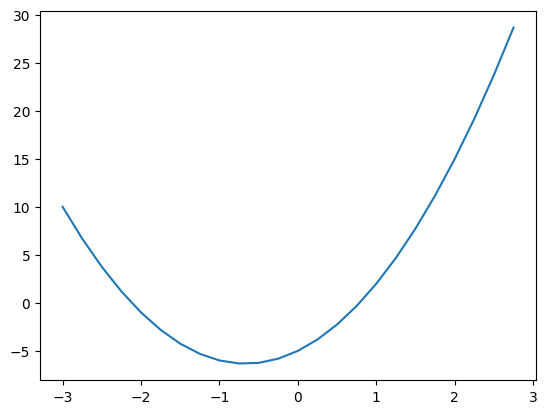

In [18]:
ys = np.arange(-3,3,0.25)
r = f(ys)
plt.plot(ys,r)

${\displaystyle L=\lim _{h\to 0}{\frac {f(a+h)-f(a)}{h}}}$

Here we know that the h here is the smallest hyper parameter which we will add to input and learn how does it respond to it either by increasing slope or decreasing slope


lets differentiate and find out the slope manually:
equation:
${3x^2+4x-5}$

derivative of it:
${6x+4}$

so lets take x = 3.0 same input as above and answer is:

${22.00..}$

In [19]:
h = 0.01
x = 3.0
(f(x+h)-f(x))/h
#this is slope :)

22.02999999999946

## it's getting dirty :)

In [20]:
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


In [21]:
#bumping a
h = 0.0001

a = 2.0

b = -3.0
c = 10.0
d1 = a*b+c
a = a+h
d2 = a*b+c
print(d1)
print(d2)
print(f'derviative of this: {(d2-d1)/h}') #as we are doing with respect to a, so the derivative of this 
#equation is: b which = -3.0
#so in this way we will have more complex equations to derivate and that is impossible if we have to do through hardcoding

4.0
3.999699999999999
derviative of this: -3.000000000010772


# lets start MiniAutoGrad

In [22]:
class Value:
    def __init__(self,data):
        self.data = data

a = Value(2.0)
a

In [23]:
#lets make it beautiful by using __repr__
class Value:
    def __init__(self,data):
        self.data = data
    def __repr__(self):
        return f'Value(data= {self.data})'

   
a = Value(2.0)
b = Value(3.0)
a,b


(Value(data= 2.0), Value(data= 3.0))

In [24]:
#If i want to perform operations like basic arithmetic operations on this
a+b

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [25]:
#lets solve this
class Value:
    def __init__(self,data):
        self.data = data

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        return Value(self.data+other.data)

a = Value(2.0)
b = Value(3.0)
a+b

#here '+' operator is mapped to something this kind of format by python internally: "a.__add__(b)""

Value(data= 5.0)

In [26]:
#similarly lets solve for all basic arithmetic operations
class Value:
    def __init__(self,data):
        self.data = data

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        return Value(self.data+other.data)
    
    def __sub__(self,other):
        return Value(self.data-other.data)

    def __mul__(self,other):
        return Value(self.data*other.data)

#lets try with multiple operations
a,b,c = Value(2.0),Value(-3.0),Value(5.5)
(a*b)-c

Value(data= -11.5)

## now we dive into the core part:

as we know when we are dealing with multiple equation or
a equation which is depended on other equations, we need to keep track of those so for this -> we will use a graph(DAG)
DAG - Directed acyclic graph
in that we will use pointers called as children(though it's not mandatory you can rename it :) )

In [27]:
class Value:
    def __init__(self,data,_children=()):
        self.data = data
        self._prev = set(_children) #reason unknown maybe for efficiency
    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        return Value(self.data+other.data,(self,other))
    
    def __sub__(self,other):
        return Value(self.data-other.data,(self,other)) #this is like Value(data,_children())

    def __mul__(self,other):
        return Value(self.data*other.data,(self,other))
    
a,b,c = Value(2.0),Value(-3.0),Value(5.5)
d = (a*b)-c
d._prev

{Value(data= -6.0), Value(data= 5.5)}

looks good so far we were able to keep track of previous equations or dependencies.

Now, if you had carefully observed we still didn't solve the issue of tracking of operations used.

Lets go

In [4]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""): #adding op pointer
        self.data = data
        self.label=label
        self.grad = 0.0
        self._prev = set(_children) 
        self._op = _op

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        return Value(self.data+other.data,(self,other),'+')
    
    def __sub__(self,other):
        return Value(self.data-other.data,(self,other),'-') 

    def __mul__(self,other):
        return Value(self.data*other.data,(self,other),'*') #this is like: " Value(data,_children(),_op) "
    
    
    
    
a,b,c = Value(2.0,label='a'),Value(-3.0,label='b'),Value(5.5,label='c')
d = (a*b)-c
d.label='d'
print(f'value: {d}, prev: {d._prev}, operators: {d._op}')

value: Value(data= -11.5), prev: {Value(data= -6.0), Value(data= 5.5)}, operators: -


## Now as we move on, the equations gets more bigger and complex, but the above code is hard to visualize when things get bigger

so for this we need to do something we can visualise the entire process clearrly

In [1]:
!pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)


In [5]:
from graphviz import Digraph

def trace(root):
    #this is to build a set of all nodes and edges required for graph
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format = 'svg',graph_attr={'rankdir':'LR'})#LR = left to right
    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label="{%s|data %.4f|grad %.2f}"%(n.label,n.data,n.grad),shape='record')
        if n._op:
            dot.node(name=uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
        
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot

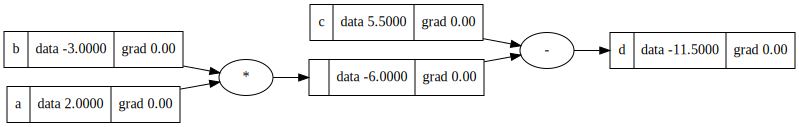

In [6]:
draw_dot(d)

here grads represents derivative of that value w.r.t to the final output

lets take example of d:
${d(D)=1}$

lets take example of a:
${d/da(ab+c) = b}$

In [7]:
#lets try to compute grad manually or by code

def compute():
    h = 0.0001
    a = Value(2.0,label="a")
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a+b;e.label='e'
    d = e+c;d.label='d'
    f = Value(-2.0,label='f')
    L = d*f;L.label='L'
    L1 = L.data

    a = Value(2.0,label="a") #we added h
    b = Value(-3.0,label='b')
    c = Value(10.0,label='c')
    e = a+b;e.label='e'
    d = e+c;d.label='d'
    f = Value(-2.0,label='f')
    L = d*f;L.label='L'
    L2 = L.data+h

    slope = (L2-L1)/h
    print(f'slope: {(L2-L1)/h}')

compute()

slope: 0.9999999999976694


In [9]:
h = 0.0001
a = Value(2.0,label="a") 
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b;e.label='e'
d = e+c;d.label='d'
f = Value(-2.0,label='f')
L = d*f;L.label='L'
L2 = L.data+h
L.grad=1.0

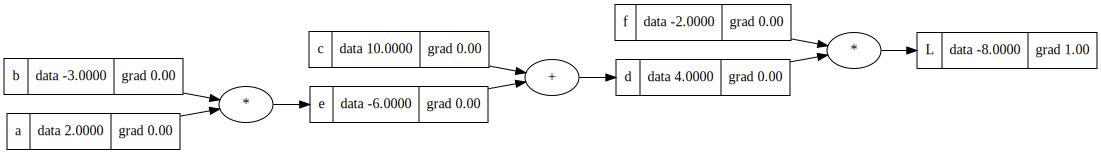

In [10]:
draw_dot(L)

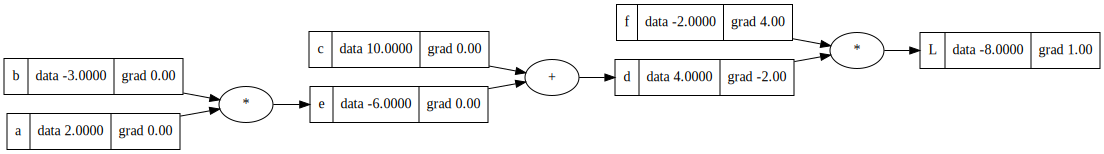

In [11]:
#lets compute derivative for f
#we know L = d*f and we want to calculate dL/dd
#so dL/dd = f
#so 
d.grad = f.data
#and similarly for dL/df = d
f.grad = d.data
draw_dot(L)


## the crux of chain rule and probably back propagation

#lets find out dL/dc
we know that to find out dl/dc we need to find out something in between or the relation between c and l

L depends on f and d
d depends on e and c

That's it!! here we go, 

We just computed that dL/dd = f , now we need to find dd/dc , d = e+c 
so dd/dc = 1

and there is something as chain rule:
${{\displaystyle {\frac {dz}{dx}}={\frac {dz}{dy}}\cdot {\frac {dy}{dx}},}}$

${\displaystyle{{\frac {dL}{dc}} = {\frac {dL}{dd}} \cdot{\frac {dd}{dc}}}}$

which equals to

${\displaystyle{{\frac {dL}{dc}}= {f}\cdot{1} = f}}$

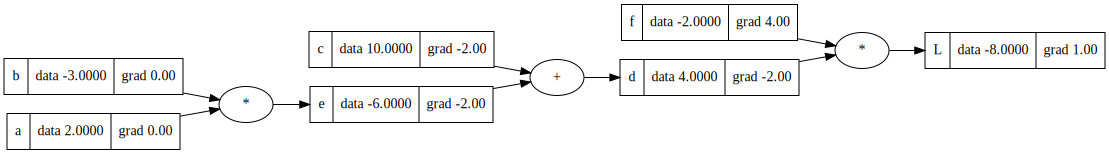

In [12]:
c.grad = f.data
e.grad = f.data
draw_dot(L)

In [13]:
#lets verify with the derivative formula:
h = 0.0001
a = Value(2.0,label="a") 
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b;e.label='e'
d = e+c;d.label='d'
f = Value(-2.0,label='f')
L = d*f;L.label='L'
L1 = L.data


a = Value(2.0,label="a") 
b = Value(-3.0,label='b')
c = Value(10.0,label='c')
e = a*b;e.label='e'
c.data+=h
d = e+c;d.label='d'
c.data+=h
f = Value(-2.0,label='f')
L = d*f;L.label='L'
L2 = L.data

(L2-L1)/h

-1.9999999999953388

In [14]:
L.grad = 1.0
d.grad = f.data
#and similarly for dL/df = d
f.grad = d.data
c.grad = f.data
e.grad = f.data

now lets this makes us familiar with chain rule:

${\displaystyle{{\frac{dL}{dc}} = {\frac{dL}{dd}}\cdot{\frac{dd}{de}}\cdot{\frac{de}{da}}}}$

which is 

${\displaystyle{{\frac{de}{da}}={\frac{d}{da}({a}\cdot{b})}=b}}$

${\displaystyle{{\frac{dL}{da}}={f}\cdot{1}\cdot{b}}}$

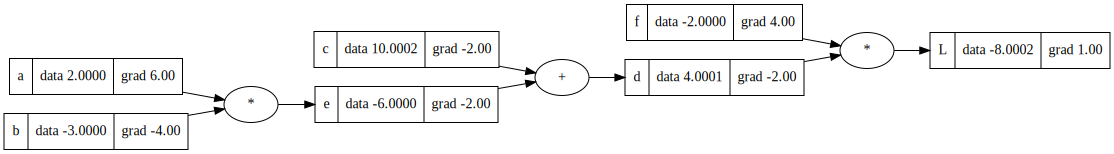

In [15]:
a.grad = (f.data*b.data)
b.grad = (f.data*a.data)
draw_dot(L)

### lets do backpropagation for a simple two layer NN

In [22]:
x1 = Value(2.0,label='x1')
x2 = Value(4.0,label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
xw_1 = x1*w1;xw_1.label='x1w1'
xw_2 = x2*w2;xw_2.label = 'x2w2'
b = Value(6.7,label='b')
xw = xw_1 + xw_2
xw.label = 'x1w1x2w2'
n = xw+b;n.label = 'n'
#now as we need to add a activation function we need to implement or add the method in our Value class lets do it

In [19]:
import math
class Value:
    def __init__(self,data,_children=(),_op="",label=""): #adding op pointer
        self.data = data
        self.label=label
        self.grad = 0.0
        self._prev = set(_children) 
        self._op = _op

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        return Value(self.data+other.data,(self,other),'+')
    
    def __sub__(self,other):
        return Value(self.data-other.data,(self,other),'-') 

    def __mul__(self,other):
        return Value(self.data*other.data,(self,other),'*')

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        return out

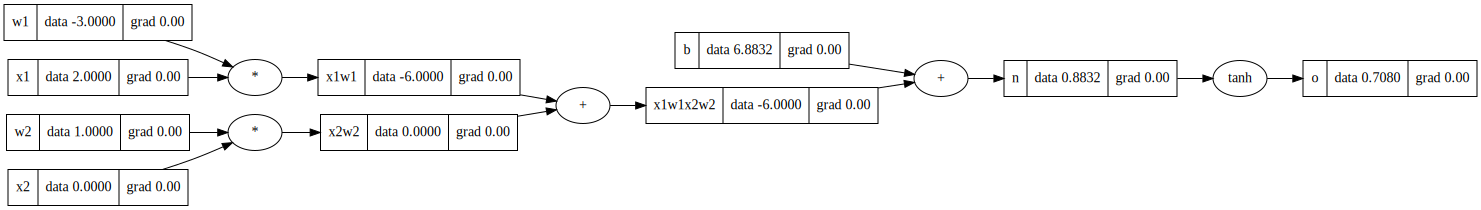

In [52]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
xw_1 = x1*w1;xw_1.label='x1w1'
xw_2 = x2*w2;xw_2.label = 'x2w2'
b = Value(6.883175,label='b')
xw = xw_1 + xw_2
xw.label = 'x1w1x2w2'
n = xw+b;n.label = 'n'
o = n.tanh();o.label='o'
draw_dot(o)

In [28]:
#we know do/d0 = 1.0
o.grad = 1.0
n.grad=(1-o.data**2)*o.grad#do/dn = d/dn(tanh(n))
#we know '+' op is a distributor of grad to local derivative so,
b.grad = (1-o.data**2) * o.grad
xw.grad = (1-o.data**2)*o.grad
#similarly for:
xw_1.grad = (1-o.data**2)*o.grad
xw_2.grad = (1-o.data**2)*o.grad
#w1 = (do/dn)*(dn/dxw)*(dxw/dw1)
#dxw/dw1 = x1
#similary for w2 = x2

w1.grad = x1.data*xw_1.grad
x1.grad = w1.data*xw_1.grad
w2.grad = x2.data*xw_2.grad 
x2.grad = w2.data*xw_2.grad

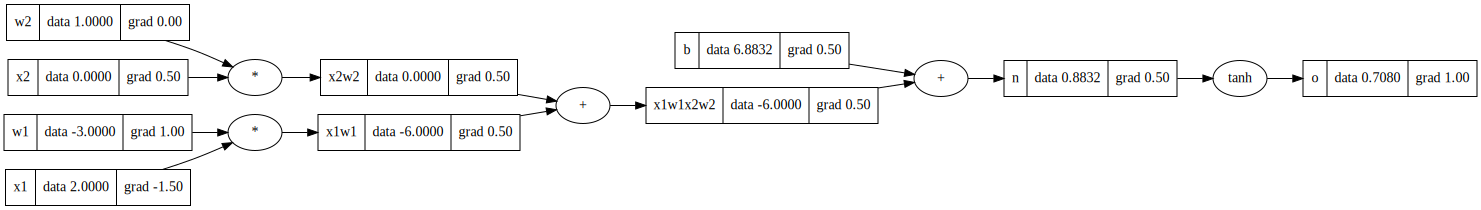

In [29]:
draw_dot(o)

## observations:
1) add backward_fn(): is the outward grad
2) mul backward_fn(): is the other.data * out.grad
3) tanh backward_fn(): is the derivative of tanh(out)*out.grad

### Now lets automate this:

In [53]:
import math
class Value:
    def __init__(self,data,_children=(),_op="",label=""): 
        self.data = data
        self.label=label
        self.grad = 0.0
        self._prev = set(_children) 
        self._backward = lambda:None
        self._op = _op

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        def _backward(): #we know addition operation is distribution of derivatives of local gradients
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out._backward = _backward
        return out 

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad = other.data*out.grad
            other.grad = self.data*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad =(1-t**2)*out.grad
        out._backward = _backward
        return out



In [54]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
xw_1 = x1*w1;xw_1.label='x1w1'
xw_2 = x2*w2;xw_2.label = 'x2w2'
b = Value(6.883175,label='b')
xw = xw_1 + xw_2
xw.label = 'x1w1x2w2'
n = xw+b;n.label = 'n'
o = n.tanh();o.label='o'
#we know o.grad = 1.0
o.grad = 1.0



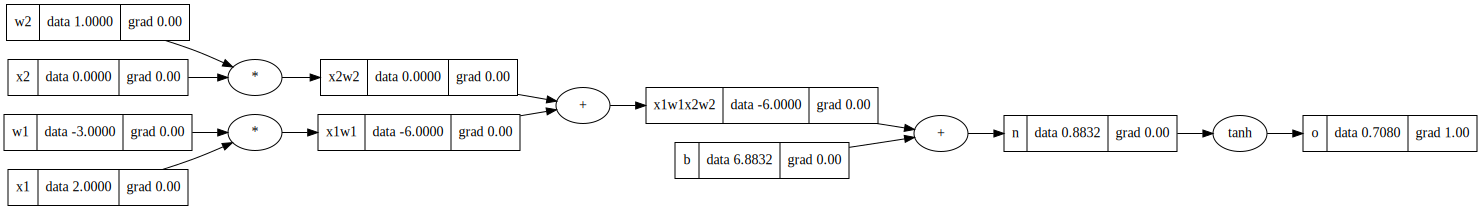

In [55]:
draw_dot(o)

In [56]:
o._backward()
n._backward()
xw._backward()
xw_1._backward()
xw_2._backward()

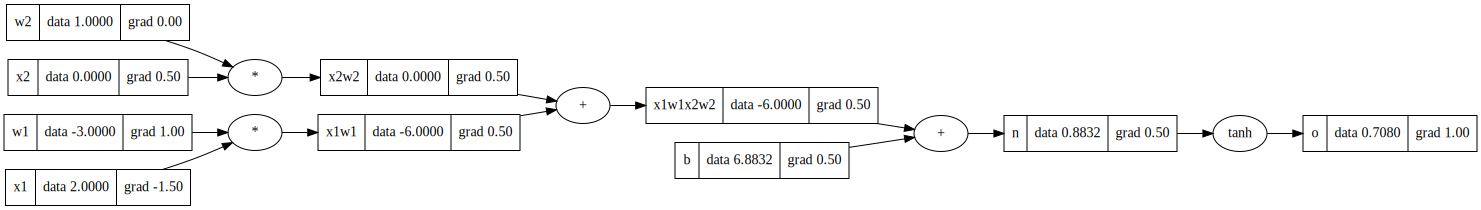

In [57]:
#it worked :)
draw_dot(o)

## now we need to make it more automatic by using something called as topological sort

In [58]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data= 1.0),
 Value(data= 0.0),
 Value(data= 0.0),
 Value(data= 2.0),
 Value(data= -3.0),
 Value(data= -6.0),
 Value(data= -6.0),
 Value(data= 6.883175),
 Value(data= 0.8831749999999996),
 Value(data= 0.7080063408524188)]

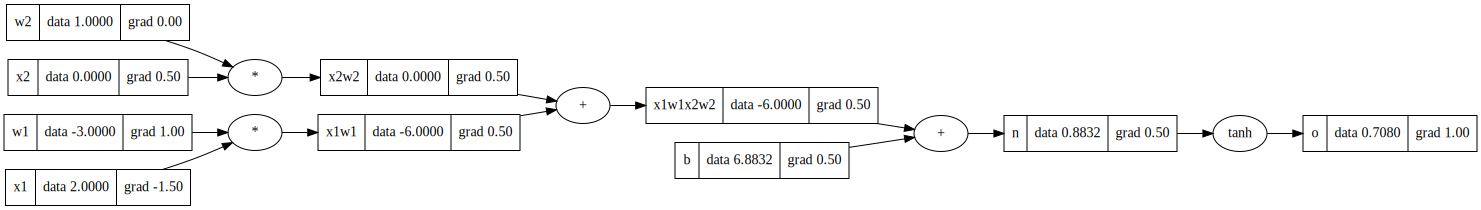

In [ ]:
#as we can observe the last value in the list is the output value

#so..
o.grad = 1.0
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

draw_dot(o)#lets gooo

### lets hide it by abstracting it

In [ ]:
import math
class Value:
    def __init__(self,data,_children=(),_op="",label=""): 
        self.data = data
        self.label=label
        self.grad = 0.0
        self._prev = set(_children) 
        self._backward = lambda:None
        self._op = _op

    def __repr__(self):
        return f'Value(data= {self.data})'

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out 

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad +=(1-t**2)*out.grad
        out._backward = _backward
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)#here o->self
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

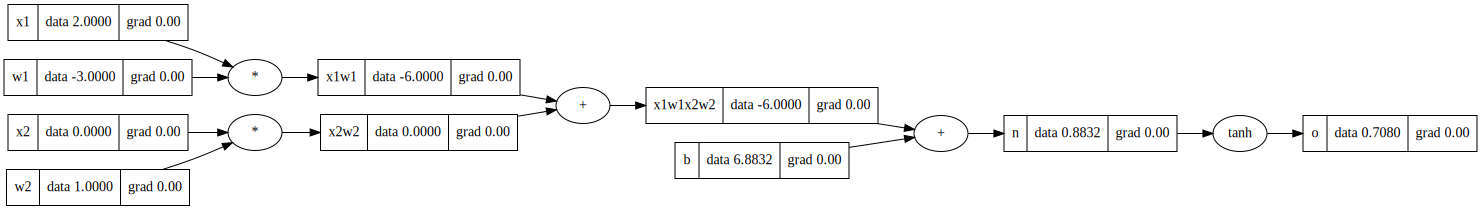

In [61]:
x1 = Value(2.0,label='x1')
x2 = Value(0.0,label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0,label='w2')
xw_1 = x1*w1;xw_1.label='x1w1'
xw_2 = x2*w2;xw_2.label = 'x2w2'
b = Value(6.883175,label='b')
xw = xw_1 + xw_2
xw.label = 'x1w1x2w2'
n = xw+b;n.label = 'n'
o = n.tanh();o.label='o'

draw_dot(o)

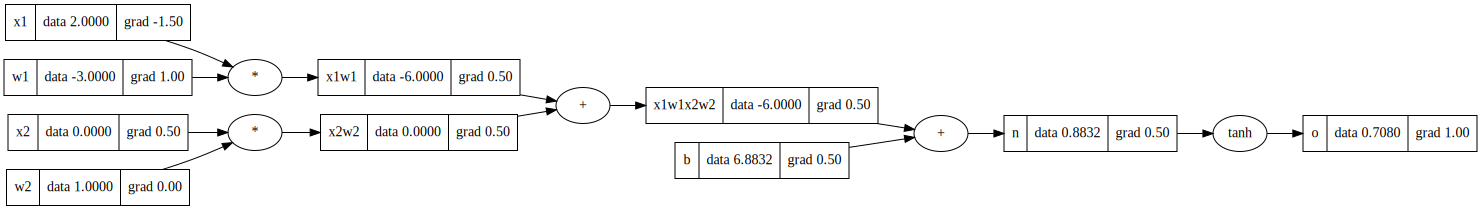

In [63]:
o.backward()
draw_dot(o)